In [ ]:


!pip install -q catboost shap scikit-learn pandas numpy matplotlib
# Optional:
!pip install -q xgboost lightgbm

import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, Any, List, Tuple, Optional

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.utils import resample

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 0) Optional imports (XGB / LGBM)
# -------------------------
HAS_XGB = False
HAS_LGBM = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

# -------------------------
# 1) Load & clean
# -------------------------
CSV_PATH = "/content/dataset2_689.csv.csv"   # <-- change if needed
df = pd.read_csv(CSV_PATH)

drop_cols = [c for c in ["Customer_ID", "Unnamed: 0"] if c in df.columns]
y_raw = df["class"].copy()
X_raw = df.drop(columns=drop_cols + ["class"], errors="ignore").copy()

# ensure binary labels
if y_raw.dtype == "O":
    y_tmp = y_raw.astype(str).str.lower().map({"1":1, "0":0, "true":1, "false":0, "yes":1, "no":0})
    if y_tmp.isna().any():
        y = pd.factorize(y_raw)[0]
    else:
        y = y_tmp.astype(int).to_numpy()
else:
    y = y_raw.astype(int).to_numpy()

X = X_raw.copy()

# -------------------------
# 2) Feature Engineering (row-wise only; safe in CV)
# -------------------------
def add_features(X_in: pd.DataFrame) -> pd.DataFrame:
    Xf = X_in.copy()

    if "A_7" in Xf.columns and "A_2" in Xf.columns:
        Xf["A7_A2_Diff"] = Xf["A_7"] - (Xf["A_2"] * 0.1)

    if "A_14" in Xf.columns and "A_3" in Xf.columns:
        Xf["A14_Stability"] = np.log1p(np.clip(Xf["A_14"], a_min=0, a_max=None)) / (Xf["A_3"] + 1)

    return Xf

# categorical candidates (your earlier assumption)
cat_cols = [c for c in ["A_1","A_4","A_6","A_8","A_9","A_11","A_12"] if c in X.columns]

# For one-hot pipelines, cast categoricals to string consistently
def cast_cats_to_str(X_in: pd.DataFrame, cat_columns: List[str]) -> pd.DataFrame:
    Xc = X_in.copy()
    for c in cat_columns:
        if c in Xc.columns:
            Xc[c] = Xc[c].astype(str)
    return Xc

# For CatBoost, ints or strings both fine; keep consistent
def cast_cats_for_catboost(X_in: pd.DataFrame, cat_columns: List[str]) -> pd.DataFrame:
    Xc = X_in.copy()
    for c in cat_columns:
        if c in Xc.columns:
            try:
                Xc[c] = Xc[c].astype(int)
            except Exception:
                Xc[c] = Xc[c].astype(str)
    return Xc

# -------------------------
# 3) Threshold tuning (done in inner CV only)
# -------------------------
def tune_threshold(y_true: np.ndarray, y_proba: np.ndarray, metric: str = "f1") -> Tuple[float, float]:
    thresholds = np.linspace(0.05, 0.95, 181)
    best_t, best_s = 0.5, -np.inf

    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        if metric == "accuracy":
            s = accuracy_score(y_true, pred)
        elif metric == "f1":
            s = f1_score(y_true, pred, zero_division=0)
        elif metric == "youden":
            tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
            tpr = tp/(tp+fn) if (tp+fn) else 0.0
            fpr = fp/(fp+tn) if (fp+tn) else 0.0
            s = tpr - fpr
        else:
            raise ValueError("metric must be one of: accuracy, f1, youden")

        if s > best_s:
            best_s, best_t = s, float(t)

    return best_t, float(best_s)

# -------------------------
# 4) Model wrappers (CatBoost handled separately)
# -------------------------
def make_preprocessor_for_ohe(X_example: pd.DataFrame, cat_columns: List[str]) -> ColumnTransformer:
    num_cols = [c for c in X_example.columns if c not in cat_columns]
    # RobustScaler only on numeric; if non-numeric in num cols, it will error
    # So we force numeric selection here:
    # (for unnamed A_* usually numeric; if any are object, you should treat them as cat)
    numeric_cols = []
    for c in num_cols:
        if pd.api.types.is_numeric_dtype(X_example[c]):
            numeric_cols.append(c)
        else:
            # fallback: treat as categorical if object
            if c not in cat_columns:
                cat_columns = cat_columns + [c]

    num_cols = numeric_cols
    cat_cols_local = [c for c in cat_columns if c in X_example.columns]

    return ColumnTransformer(
        transformers=[
            ("num", RobustScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_local)
        ],
        remainder="drop",
        sparse_threshold=0.3
    )

def get_metrics(y_true, y_proba, threshold: float) -> Dict[str, float]:
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

# -------------------------
# 5) Nested CV runner for sklearn pipelines (LR/RF/XGB/LGBM)
# -------------------------
@dataclass
class ModelSpec:
    name: str
    make_pipeline: Any                      # function(X_train)->Pipeline
    param_grid: List[Dict[str, Any]]        # list of dicts with estimator params
    threshold_metric: str = "f1"            # threshold tuning target
    selection_metric: str = "avg_auc"       # inner selection: "avg_auc" or "pr_auc" or "roc_auc"

def inner_score(y_true, y_proba, which: str):
    if which == "roc_auc":
        return roc_auc_score(y_true, y_proba)
    if which == "pr_auc":
        return average_precision_score(y_true, y_proba)
    if which == "avg_auc":
        return 0.5 * roc_auc_score(y_true, y_proba) + 0.5 * average_precision_score(y_true, y_proba)
    raise ValueError("selection_metric must be one of: roc_auc, pr_auc, avg_auc")

def run_nested_cv_sklearn(
    X_all: pd.DataFrame, y_all: np.ndarray,
    spec: ModelSpec,
    outer_splits: int = 5,
    inner_splits: int = 4,
) -> pd.DataFrame:

    outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=RANDOM_STATE)

    rows = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_all, y_all), start=1):
        X_train_raw = add_features(X_all.iloc[train_idx])
        X_test_raw  = add_features(X_all.iloc[test_idx])

        # For OHE models, cast categoricals to string
        X_train_raw = cast_cats_to_str(X_train_raw, cat_cols)
        X_test_raw  = cast_cats_to_str(X_test_raw,  cat_cols)

        # choose best cfg + threshold using inner CV
        best_cfg = None
        best_inner = -np.inf
        best_t = 0.5

        for cfg in spec.param_grid:
            inner_scores = []
            inner_ts = []

            for tr_i, va_i in inner_cv.split(X_train_raw, y_all[train_idx]):
                X_tr = X_train_raw.iloc[tr_i]
                y_tr = y_all[train_idx][tr_i]
                X_va = X_train_raw.iloc[va_i]
                y_va = y_all[train_idx][va_i]

                pipe = spec.make_pipeline(X_tr).set_params(**cfg)
                pipe.fit(X_tr, y_tr)

                y_proba = pipe.predict_proba(X_va)[:, 1]
                t, _ = tune_threshold(y_va, y_proba, metric=spec.threshold_metric)

                inner_scores.append(inner_score(y_va, y_proba, spec.selection_metric))
                inner_ts.append(t)

            mean_score = float(np.mean(inner_scores))
            mean_t = float(np.mean(inner_ts))

            if mean_score > best_inner:
                best_inner = mean_score
                best_cfg = cfg
                best_t = mean_t

        # fit final on full outer-train with chosen cfg
        final_pipe = spec.make_pipeline(X_train_raw).set_params(**best_cfg)
        final_pipe.fit(X_train_raw, y_all[train_idx])

        y_proba_test = final_pipe.predict_proba(X_test_raw)[:, 1]
        m = get_metrics(y_all[test_idx], y_proba_test, best_t)

        rows.append({
            "model": spec.name,
            "fold": fold,
            "chosen_threshold": float(best_t),
            "best_inner_score": float(best_inner),
            "best_params": best_cfg,
            **m
        })

    return pd.DataFrame(rows)

# -------------------------
# 6) CatBoost nested CV (separate: native categorical handling, no OHE)
# -------------------------
from catboost import CatBoostClassifier, Pool

def run_nested_cv_catboost(
    X_all: pd.DataFrame, y_all: np.ndarray,
    cat_columns: List[str],
    param_grid: List[Dict[str, Any]],
    threshold_metric: str = "f1",
    selection_metric: str = "avg_auc",
    outer_splits: int = 5,
    inner_splits: int = 4,
) -> Tuple[pd.DataFrame, List[Tuple[CatBoostClassifier, pd.DataFrame, List[int]]]]:

    outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=RANDOM_STATE)

    rows = []
    saved_models = []  # for SHAP stability and counterfactuals: (model, X_train_processed, cat_idx)

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_all, y_all), start=1):
        X_train = cast_cats_for_catboost(add_features(X_all.iloc[train_idx]), cat_columns)
        X_test  = cast_cats_for_catboost(add_features(X_all.iloc[test_idx]),  cat_columns)

        feat_names = X_train.columns.tolist()
        cat_idx = [feat_names.index(c) for c in cat_columns if c in feat_names]

        # inner selection
        best_cfg, best_inner, best_t = None, -np.inf, 0.5

        for cfg in param_grid:
            inner_scores = []
            inner_ts = []

            for tr_i, va_i in inner_cv.split(X_train, y_all[train_idx]):
                X_tr = X_train.iloc[tr_i]
                y_tr = y_all[train_idx][tr_i]
                X_va = X_train.iloc[va_i]
                y_va = y_all[train_idx][va_i]

                tr_pool = Pool(X_tr, y_tr, cat_features=cat_idx)
                va_pool = Pool(X_va, y_va, cat_features=cat_idx)

                model = CatBoostClassifier(
                    **cfg,
                    loss_function="Logloss",
                    eval_metric="AUC",
                    random_seed=RANDOM_STATE,
                    verbose=False
                )
                model.fit(tr_pool, eval_set=va_pool, use_best_model=True)

                proba_va = model.predict_proba(va_pool)[:, 1]
                t, _ = tune_threshold(y_va, proba_va, metric=threshold_metric)

                inner_scores.append(inner_score(y_va, proba_va, selection_metric))
                inner_ts.append(t)

            mean_score = float(np.mean(inner_scores))
            mean_t = float(np.mean(inner_ts))
            if mean_score > best_inner:
                best_inner, best_cfg, best_t = mean_score, cfg, mean_t

        # fit final model on full outer-train
        train_pool = Pool(X_train, y_all[train_idx], cat_features=cat_idx)
        test_pool  = Pool(X_test,  y_all[test_idx],  cat_features=cat_idx)

        final_model = CatBoostClassifier(
            **best_cfg,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=RANDOM_STATE,
            verbose=False
        )
        final_model.fit(train_pool)

        proba_test = final_model.predict_proba(test_pool)[:, 1]
        m = get_metrics(y_all[test_idx], proba_test, best_t)

        rows.append({
            "model": "CatBoost",
            "fold": fold,
            "chosen_threshold": float(best_t),
            "best_inner_score": float(best_inner),
            "best_params": best_cfg,
            **m
        })

        saved_models.append((final_model, X_train.copy(), cat_idx))

    return pd.DataFrame(rows), saved_models

# -------------------------
# 7) Define baseline suite specs
# -------------------------
def make_lr_pipeline(X_train_example: pd.DataFrame) -> Pipeline:
    pre = make_preprocessor_for_ohe(X_train_example, cat_cols.copy())
    lr = LogisticRegression(max_iter=5000, solver="lbfgs")
    return Pipeline([("pre", pre), ("clf", lr)])

def make_rf_pipeline(X_train_example: pd.DataFrame) -> Pipeline:
    pre = make_preprocessor_for_ohe(X_train_example, cat_cols.copy())
    rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    return Pipeline([("pre", pre), ("clf", rf)])

def make_xgb_pipeline(X_train_example: pd.DataFrame) -> Pipeline:
    pre = make_preprocessor_for_ohe(X_train_example, cat_cols.copy())
    xgb = XGBClassifier(
        random_state=RANDOM_STATE,
        n_estimators=600,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1
    )
    return Pipeline([("pre", pre), ("clf", xgb)])

def make_lgbm_pipeline(X_train_example: pd.DataFrame) -> Pipeline:
    pre = make_preprocessor_for_ohe(X_train_example, cat_cols.copy())
    lgbm = LGBMClassifier(random_state=RANDOM_STATE, n_estimators=800, n_jobs=-1)
    return Pipeline([("pre", pre), ("clf", lgbm)])

lr_spec = ModelSpec(
    name="LogReg(OHE)",
    make_pipeline=make_lr_pipeline,
    param_grid=[
        {"clf__C": 0.1},
        {"clf__C": 1.0},
        {"clf__C": 10.0},
    ],
    threshold_metric="f1",
    selection_metric="avg_auc"
)

rf_spec = ModelSpec(
    name="RandomForest(OHE)",
    make_pipeline=make_rf_pipeline,
    param_grid=[
        {"clf__n_estimators": 600, "clf__max_depth": None, "clf__min_samples_leaf": 1},
        {"clf__n_estimators": 800, "clf__max_depth": 10,   "clf__min_samples_leaf": 2},
        {"clf__n_estimators": 800, "clf__max_depth": 6,    "clf__min_samples_leaf": 3},
    ],
    threshold_metric="f1",
    selection_metric="avg_auc"
)

xgb_spec = ModelSpec(
    name="XGBoost(OHE)",
    make_pipeline=make_xgb_pipeline,
    param_grid=[
        {"clf__max_depth": 3, "clf__learning_rate": 0.05, "clf__subsample": 0.9, "clf__colsample_bytree": 0.9},
        {"clf__max_depth": 4, "clf__learning_rate": 0.03, "clf__subsample": 0.9, "clf__colsample_bytree": 0.9},
        {"clf__max_depth": 3, "clf__learning_rate": 0.08, "clf__subsample": 0.8, "clf__colsample_bytree": 0.8},
    ],
    threshold_metric="f1",
    selection_metric="avg_auc"
)

lgbm_spec = ModelSpec(
    name="LightGBM(OHE)",
    make_pipeline=make_lgbm_pipeline,
    param_grid=[
        {"clf__num_leaves": 31, "clf__learning_rate": 0.05, "clf__subsample": 0.9, "clf__colsample_bytree": 0.9},
        {"clf__num_leaves": 31, "clf__learning_rate": 0.03, "clf__subsample": 0.9, "clf__colsample_bytree": 0.9},
        {"clf__num_leaves": 15, "clf__learning_rate": 0.08, "clf__subsample": 0.8, "clf__colsample_bytree": 0.8},
    ],
    threshold_metric="f1",
    selection_metric="avg_auc"
)

# CatBoost grid (small, defensible)
catboost_grid = [
    dict(iterations=1200, learning_rate=0.02, depth=5, l2_leaf_reg=10, random_strength=1.5, bagging_temperature=0.7),
    dict(iterations=1500, learning_rate=0.01, depth=5, l2_leaf_reg=15, random_strength=2.0, bagging_temperature=1.0),
    dict(iterations=800,  learning_rate=0.03, depth=4, l2_leaf_reg=5,  random_strength=1.0, bagging_temperature=0.5),
]

# -------------------------
# 8) Run experiments
# -------------------------
all_results = []

# Baselines
all_results.append(run_nested_cv_sklearn(X, y, lr_spec))
all_results.append(run_nested_cv_sklearn(X, y, rf_spec))

if HAS_XGB:
    all_results.append(run_nested_cv_sklearn(X, y, xgb_spec))
else:
    print("XGBoost not installed -> skipping XGBoost baseline. (pip install xgboost)")

if HAS_LGBM:
    all_results.append(run_nested_cv_sklearn(X, y, lgbm_spec))
else:
    print("LightGBM not installed -> skipping LightGBM baseline. (pip install lightgbm)")

# CatBoost (native categorical)
cat_res, cat_models = run_nested_cv_catboost(
    X, y,
    cat_columns=cat_cols,
    param_grid=catboost_grid,
    threshold_metric="f1",
    selection_metric="avg_auc",
    outer_splits=5,
    inner_splits=4
)
all_results.append(cat_res)

results_df = pd.concat(all_results, ignore_index=True)

print("\n=== Outer-fold results (unbiased) ===")
display(results_df)

print("\n=== Mean ± Std by model ===")
summary = results_df.groupby("model")[["accuracy","f1","precision","recall","roc_auc","pr_auc"]].agg(["mean","std"])
display(summary)

# ============================================================
# 9) SHAP Stability Analysis (bootstrap SHAP importances on OUTER-TRAIN only)
#    This is analysis-only; it does NOT alter model selection.
# ============================================================
import shap

def shap_stability_bootstrap_catboost(
    model: CatBoostClassifier,
    X_train: pd.DataFrame,
    cat_idx: List[int],
    n_bootstrap: int = 30,
    sample_size: int = 250,
    random_state: int = RANDOM_STATE
) -> pd.DataFrame:
    """
    Returns per-feature mean SHAP importance and its bootstrap std (lower std = more stable).
    Uses only the provided training set.
    """
    rng = np.random.RandomState(random_state)
    cols = X_train.columns.tolist()

    importances = []

    # Use TreeExplainer for CatBoost
    explainer = shap.TreeExplainer(model)

    for b in range(n_bootstrap):
        Xb = resample(
            X_train,
            replace=True,
            n_samples=min(sample_size, len(X_train)),
            random_state=rng.randint(0, 10_000_000)
        )
        pool_b = Pool(Xb, cat_features=cat_idx)
        shap_vals = explainer.shap_values(pool_b)

        # For binary classification, shap_values often returns (n_samples, n_features)
        # If list returned, take class 1
        if isinstance(shap_vals, list):
            shap_arr = np.array(shap_vals[1])
        else:
            shap_arr = np.array(shap_vals)

        mean_abs = np.abs(shap_arr).mean(axis=0)
        importances.append(mean_abs)

    importances = np.vstack(importances)  # (B, F)

    mean_imp = importances.mean(axis=0)
    std_imp = importances.std(axis=0)

    out = pd.DataFrame({
        "feature": cols,
        "mean_abs_shap": mean_imp,
        "bootstrap_std": std_imp,
        "stability_score(std/mean)": std_imp / (mean_imp + 1e-12)
    }).sort_values("stability_score(std/mean)")

    return out

print("\n=== SHAP Stability (CatBoost) per outer fold ===")
shap_stability_tables = []
for i, (m, Xtr, cat_idx) in enumerate(cat_models, start=1):
    stab = shap_stability_bootstrap_catboost(m, Xtr, cat_idx, n_bootstrap=20, sample_size=250)
    stab["fold"] = i
    shap_stability_tables.append(stab)

shap_stability_df = pd.concat(shap_stability_tables, ignore_index=True)
display(shap_stability_df.head(30))

print("\n=== SHAP Stability aggregated across folds (mean stability_score) ===")
agg_stab = shap_stability_df.groupby("feature")[["mean_abs_shap","bootstrap_std","stability_score(std/mean)"]].mean().sort_values("stability_score(std/mean)")
display(agg_stab)

# ============================================================
# 10) Constraint-aware Counterfactual Search (outer-train only)
#    Goal: change actionable numeric features minimally to flip prediction below threshold.
#    This is a baseline recourse method; for journals compare with DiCE/Wachter if possible.
# ============================================================
def get_feature_bounds(X_ref: pd.DataFrame, cat_columns: List[str]) -> Dict[str, Tuple[float, float]]:
    bounds = {}
    for c in X_ref.columns:
        if c in cat_columns:
            continue
        if pd.api.types.is_numeric_dtype(X_ref[c]):
            bounds[c] = (float(X_ref[c].quantile(0.01)), float(X_ref[c].quantile(0.99)))
    return bounds

def predict_proba_catboost(model, x_row: pd.Series, X_cols: List[str], cat_cols: List[str], cat_idx: List[int]) -> float:
    df1 = pd.DataFrame([x_row[X_cols].to_dict()], columns=X_cols)
    df1 = cast_cats_for_catboost(df1, cat_cols)
    pool = Pool(df1, cat_features=cat_idx)
    return float(model.predict_proba(pool)[:, 1][0])

def counterfactual_shap_guided(
    model: CatBoostClassifier,
    x0: pd.Series,
    X_ref_train: pd.DataFrame,
    cat_cols: List[str],
    cat_idx: List[int],
    threshold: float,
    immutable: Optional[List[str]] = None,
    top_k: int = 6,
    max_steps: int = 400,
    step_scale: float = 0.15,
    random_restarts: int = 5,
    random_state: int = RANDOM_STATE
) -> Tuple[float, Optional[pd.Series], float, List[str]]:
    """
    SHAP-guided, bounds-constrained, numeric-only counterfactual search.
    - Keeps categoricals and immutable features fixed.
    - Perturbs top_k numeric features (by SHAP contribution) within training quantile bounds.
    - Returns: (p0, x_cf or None, L1_distance, changed_features)
    """
    if immutable is None:
        immutable = []

    rng = np.random.RandomState(random_state)

    X_cols = X_ref_train.columns.tolist()
    x0 = x0.copy()
    x0_df = cast_cats_for_catboost(pd.DataFrame([x0[X_cols]]), cat_cols)
    x0_series = x0_df.iloc[0]

    p0 = predict_proba_catboost(model, x0_series, X_cols, cat_cols, cat_idx)
    if p0 < threshold:
        return p0, None, 0.0, []

    # bounds and ranges
    bounds = get_feature_bounds(X_ref_train, cat_cols)
    ranges = {f: (hi - lo) for f, (lo, hi) in bounds.items()}

    # SHAP ranking (use one row)
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(Pool(x0_df, cat_features=cat_idx))
    if isinstance(shap_vals, list):
        shap_arr = np.array(shap_vals[1])[0]
    else:
        shap_arr = np.array(shap_vals)[0]

    shap_series = pd.Series(shap_arr, index=X_cols).sort_values(ascending=False)

    # candidate numeric, actionable features
    candidates = []
    for f in shap_series.index:
        if f in cat_cols:
            continue
        if f in immutable:
            continue
        if f not in bounds:
            continue
        candidates.append(f)
        if len(candidates) >= top_k:
            break

    if len(candidates) == 0:
        return p0, None, np.inf, []

    best = None
    best_dist = np.inf

    for r in range(random_restarts):
        x = x0_series.copy()

        # small random init within bounds for candidates
        for f in candidates:
            lo, hi = bounds[f]
            jitter = rng.uniform(-0.03, 0.03) * (ranges[f] + 1e-12)
            x[f] = float(np.clip(x[f] + jitter, lo, hi))

        step = step_scale

        for it in range(max_steps):
            x_try = x.copy()

            # coordinate-like update (reduce proba): push features opposite SHAP sign
            for f in candidates:
                lo, hi = bounds[f]
                delta = step * (ranges[f] + 1e-12)

                # If SHAP is positive (increasing fraud prob), move downward; else upward
                direction = -1.0 if shap_series[f] > 0 else 1.0
                # add small randomness
                direction *= rng.choice([0.5, 1.0, 1.5])
                x_try[f] = float(np.clip(x_try[f] + direction * delta, lo, hi))

            p_try = predict_proba_catboost(model, x_try, X_cols, cat_cols, cat_idx)

            # success: flipped below threshold
            if p_try < threshold:
                dist = float(np.sum(np.abs(x_try[candidates].values - x0_series[candidates].values)))
                if dist < best_dist:
                    best_dist = dist
                    best = x_try.copy()
                break

            # accept if decreased probability
            p_curr = predict_proba_catboost(model, x, X_cols, cat_cols, cat_idx)
            if p_try < p_curr:
                x = x_try

            # shrink step periodically
            if it > 0 and it % 80 == 0:
                step *= 0.7
                if step < 1e-4:
                    break

    if best is None:
        return p0, None, np.inf, []

    changed = []
    for f in candidates:
        if float(best[f]) != float(x0_series[f]):
            changed.append(f)

    return p0, best, best_dist, changed

# Example usage: pick a high-risk sample from fold 1 training data
print("\n=== Counterfactual example (CatBoost fold 1) ===")
model1, Xtr1, cat_idx1 = cat_models[0]

# pick the most fraud-like instance in train set (by model probability)
probas_train = []
for i in range(min(len(Xtr1), 300)):
    probas_train.append(
        predict_proba_catboost(model1, Xtr1.iloc[i], Xtr1.columns.tolist(), cat_cols, cat_idx1)
    )
idx = int(np.argmax(probas_train))
x0 = Xtr1.iloc[idx]
p0 = probas_train[idx]

# choose a threshold
fold1_threshold = float(results_df.query("model=='CatBoost' and fold==1")["chosen_threshold"].iloc[0])

p0, xcf, dist, changed = counterfactual_shap_guided(
    model=model1,
    x0=x0,
    X_ref_train=Xtr1,
    cat_cols=cat_cols,
    cat_idx=cat_idx1,
    threshold=fold1_threshold,
    immutable=[],      # put features here you do not allow to change (e.g. A_1 if it's identity-like)
    top_k=6,
    max_steps=400,
    random_restarts=6
)

print("Original predicted fraud probability:", p0)
print("Threshold used:", fold1_threshold)

if xcf is None:
    print("No counterfactual found under constraints.")
else:
    p_cf = predict_proba_catboost(model1, xcf, Xtr1.columns.tolist(), cat_cols, cat_idx1)
    print("Counterfactual predicted fraud probability:", p_cf)
    print("L1 distance on changed features:", dist)
    print("Changed features:", changed)

    # show deltas
    deltas = (xcf[changed] - x0[changed]).sort_values(key=lambda s: np.abs(s), ascending=False)
    print("\nDeltas:")
    print(deltas)

[LightGBM] [Info] Number of positive: 185, number of negative: 229
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 714
[LightGBM] [Info] Number of data points in the train set: 414, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.446860 -> initscore=-0.213366
[LightGBM] [Info] Start training from score -0.213366
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 185, number of negative: 229
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 698
[LightGBM] [Info] Number of data points in the train set: 414, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.446860 -> initscore=-0.213366
[LightGBM] [Info] Start training from score -0.213366
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 184, number of negative: 230
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 719
[LightGBM] [Info] Number of data points in the train set: 414, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.444444 -> initscore=-0.223144
[LightGBM] [Info] Start training from score -0.223144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

...


=== SHAP Stability (CatBoost) per outer fold ===


,feature,mean_abs_shap,bootstrap_std,stability_score(std/mean),fold
0,A_8,1.482412,0.014553,0.009817,1
1,A_9,0.216959,0.003627,0.016715,1
2,A_7,0.186997,0.004252,0.022738,1
3,A_11,0.025257,0.000637,0.025221,1
4,A_14,0.346695,0.011911,0.034357,1
5,A_1,0.011094,0.000416,0.037488,1
6,A7_A2_Diff,0.116954,0.004484,0.038336,1
7,A_6,0.181351,0.008596,0.047402,1
8,A_10,0.231030,0.011185,0.048414,1
9,A_4,0.216679,0.010519,0.048548,1



=== SHAP Stability aggregated across folds (mean stability_score) ===


,mean_abs_shap,bootstrap_std,stability_score(std/mean)
feature,,,
A_8,1.774157,0.014141,0.008028
A_9,0.178677,0.003841,0.021734
A_7,0.273668,0.006224,0.022853
A_14,0.444173,0.017377,0.039362
A_11,0.027221,0.001097,0.039938
A_10,0.318407,0.012786,0.040445
A_1,0.032036,0.001376,0.040470
A_5,0.413427,0.018091,0.043582
A7_A2_Diff,0.164574,0.008139,0.047625



=== Counterfactual example (CatBoost fold 1) ===
Original predicted fraud probability: 0.992953607447634
Threshold used: 0.35749999999999993
No counterfactual found under constraints.


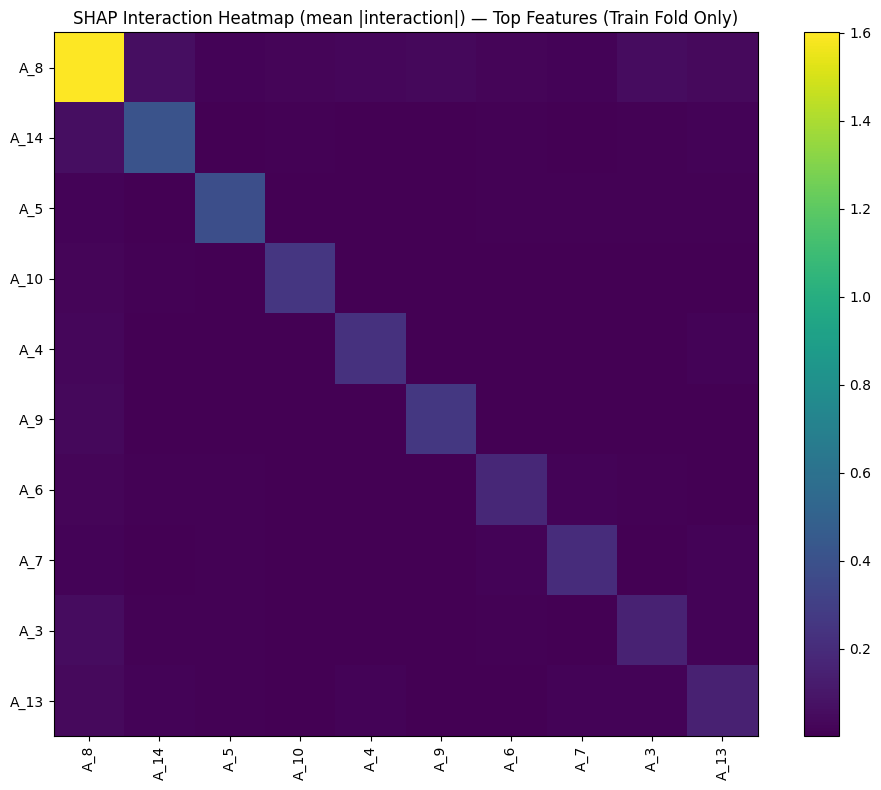

Top SHAP interaction pairs (Fold 1, Train only):


,feature_1,feature_2,mean_abs_interaction
89,A_8,A_14,0.059917
33,A_3,A_8,0.057376
88,A_8,A_13,0.039524
84,A_8,A_9,0.034003
73,A_6,A7_A2_Diff,0.027112
45,A_4,A_8,0.026294
66,A_6,A_8,0.022152
85,A_8,A_10,0.022076
87,A_8,A_12,0.021917
18,A_2,A_6,0.020789


In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from catboost import Pool

def compute_shap_values_safe(explainer, pool_or_df):
    """Return SHAP values array for binary classification (class 1)."""
    sv = explainer.shap_values(pool_or_df)
    if isinstance(sv, list):
        # class 1
        return np.array(sv[1])
    return np.array(sv)

def compute_shap_interactions_safe(explainer, pool_or_df):
    """Return SHAP interaction array for binary classification (class 1)."""
    si = explainer.shap_interaction_values(pool_or_df)
    if isinstance(si, list):
        # class 1
        return np.array(si[1])
    return np.array(si)

def shap_interaction_analysis_catboost(
    model,
    X_train: pd.DataFrame,
    cat_idx: list,
    sample_size: int = 250,
    top_k_features: int = 10,
    top_k_pairs: int = 20,
    random_state: int = 42,
    show_heatmap: bool = True
):
    """
    Leakage-safe SHAP interaction analysis:
    - uses only X_train (outer-train fold)
    - computes interactions on a sample for tractability
    - plots heatmap for top_k_features
    - returns a dataframe of top interaction pairs
    """

    # Sample to control compute
    Xs = X_train.sample(min(sample_size, len(X_train)), random_state=random_state)
    pool = Pool(Xs, cat_features=cat_idx)

    explainer = shap.TreeExplainer(model)

    # SHAP main effects (for picking top features)
    shap_vals = compute_shap_values_safe(explainer, pool)  # (n, f)
    mean_abs_main = np.abs(shap_vals).mean(axis=0)

    feature_names = X_train.columns.tolist()
    top_feat_idx = np.argsort(mean_abs_main)[::-1][:min(top_k_features, len(feature_names))]
    top_feat_names = [feature_names[i] for i in top_feat_idx]

    # SHAP interaction values: (n, f, f)
    inter_vals = compute_shap_interactions_safe(explainer, pool)

    # Mean absolute interaction matrix over samples
    mean_abs_inter = np.abs(inter_vals).mean(axis=0)  # (f, f)

    # Build top interaction pairs list excluding diagonals
    pairs = []
    f = len(feature_names)
    for i in range(f):
        for j in range(i + 1, f):
            pairs.append((feature_names[i], feature_names[j], mean_abs_inter[i, j]))

    pairs_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "mean_abs_interaction"])
    pairs_df = pairs_df.sort_values("mean_abs_interaction", ascending=False).head(top_k_pairs)

    # Heatmap of top features only (readable)
    if show_heatmap:
        idx = top_feat_idx
        heat = mean_abs_inter[np.ix_(idx, idx)]

        plt.figure(figsize=(10, 8))
        plt.imshow(heat)
        plt.xticks(range(len(top_feat_names)), top_feat_names, rotation=90)
        plt.yticks(range(len(top_feat_names)), top_feat_names)
        plt.colorbar()
        plt.title("SHAP Interaction Heatmap (mean |interaction|) — Top Features (Train Fold Only)")
        plt.tight_layout()
        plt.show()

    return pairs_df


model1, Xtr1, cat_idx1 = cat_models[0]

top_pairs_fold1 = shap_interaction_analysis_catboost(
    model=model1,
    X_train=Xtr1,
    cat_idx=cat_idx1,
    sample_size=250,
    top_k_features=10,
    top_k_pairs=20,
    random_state=RANDOM_STATE,
    show_heatmap=True
)

print("Top SHAP interaction pairs (Fold 1, Train only):")
display(top_pairs_fold1)

In [ ]:
# Aggregate top interaction pairs across folds (train-only each fold)
all_pairs = []

for fold_i, (m, Xtr, cat_idx) in enumerate(cat_models, start=1):
    pairs_df = shap_interaction_analysis_catboost(
        model=m,
        X_train=Xtr,
        cat_idx=cat_idx,
        sample_size=250,
        top_k_features=10,
        top_k_pairs=50,
        random_state=RANDOM_STATE + fold_i,
        show_heatmap=False
    )
    pairs_df["fold"] = fold_i
    all_pairs.append(pairs_df)

pairs_all = pd.concat(all_pairs, ignore_index=True)

# Aggregate (mean, std) per pair across folds
agg_pairs = (
    pairs_all
    .groupby(["feature_1", "feature_2"])["mean_abs_interaction"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
)

print("Most stable / strongest interaction pairs across folds (train-only):")
display(agg_pairs.head(30))

Most stable / strongest interaction pairs across folds (train-only):


mean       std  count
feature_1 feature_2                               
A_3       A_8            0.068689  0.030300      5
A_8       A_14           0.060196  0.023568      5
          A_13           0.056088  0.017313      5
          A_9            0.047635  0.011132      5
A_6       A7_A2_Diff     0.033613  0.016890      4
A_4       A_13           0.032702  0.017826      5
A_7       A_13           0.030557  0.021271      5
A_12      A7_A2_Diff     0.029206       NaN      1
A_13      A7_A2_Diff     0.028537  0.019485      5
A_8       A_12           0.028310  0.014234      5
          A_10           0.028020  0.005196      5
A_2       A_5            0.027572  0.019368      4
A_7       A_8            0.026966  0.006644      5
A_5       A_8            0.026927  0.011618      5
A_2       A7_A2_Diff     0.026180  0.014619      2
          A_10           0.025876       NaN      1
A_1       A_11           0.025730       NaN      1
A_4       A_8            0.025316  0.005481      5
A_13      A_14           0.025251  0.010705      5
A_5       A14_Stability  0.024778       NaN      1
A_2       A_3            0.024571  0.007346      2
A_3       A_13           0.022519  0.004862      5
A_2       A_14           0.021511  0.018458      4
          A_6            0.021394  0.014152      4
          A_13           0.020848  0.011599      5
A_8       A7_A2_Diff     0.020412  0.009614      5
A_13      A14_Stability  0.020078  0.004409      5
A_2       A14_Stability  0.019747  0.018819      3
          A_8            0.018690  0.011395      5
A_1       A_3            0.018601  0.010540      2